# Inverse Kinematics: All 8 Solutions for a 6-DOF Arm

## IK is not planning

Inverse kinematics (IK) answers a deceptively simple question:

> *"What joint angles produce this end-effector pose?"*

It is **not** motion planning. It doesn't care about obstacles, joint limits (by default), or how to get from A to B. It is purely a geometric question: given a desired 4×4 transformation matrix, which joint configurations satisfy it?

For a **6R industrial arm** (6 revolute joints), there are up to **8 kinematically distinct solutions**. Each solution places the end-effector at the exact same position and orientation, but with a completely different arm shape:

- **Elbow up vs. elbow down** (2 variants for joints 2-3)
- **Shoulder left vs. shoulder right** (2 variants for joint 1)
- **Wrist flip** (2 variants for joints 4-6: joint 5 = +θ₅ or -θ₅)

2 × 2 × 2 = **8 solutions**. Some may be unreachable (NaN) due to the geometry, but in general all 8 exist.

This notebook uses the **OPW kinematics** solver, a closed-form analytical approach that is exact and extremely fast (no iteration, no numerical methods).

In [2]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import matplotlib
# matplotlib_inline 0.2.2 calls rcParams._get() which was removed in newer matplotlib
if not hasattr(matplotlib.RcParams, '_get'):
    matplotlib.RcParams._get = lambda self, key: dict.__getitem__(self, key)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

## Setup: Create a UR5 Robot Model

The `UR5RobotModel` wraps both FK and IK behind a clean interface. `OPWParameters.make_ur5()` provides the geometric constants (link lengths, offsets) that define the UR5's kinematic structure.

In [3]:
from core.robot_model import UR5RobotModel
from core.kinematics.opw import OPWKinematics
from core.kinematics.opw_parameters import OPWParameters

robot = UR5RobotModel()
params = OPWParameters.make_ur5()
opw = OPWKinematics(robot, params)

print(f"Robot: {robot.name}")
print(f"DOF: {robot.dof()}")
lower, upper = robot.joint_limits()
print(f"Joint limits (lower): {np.round(lower, 3)}")
print(f"Joint limits (upper): {np.round(upper, 3)}")
print(f"\nOPW parameters: {params}")

Robot: UR5
DOF: 6
Joint limits (lower): [-2.967 -1.571 -1.484 -3.491 -2.618 -7.941]
Joint limits (upper): [2.967 2.705 2.618 3.491 2.618 7.941]

OPW parameters: OPWParameters(a1=0.0000, a2=-0.4250, b=0.0162, c1=0.0892, c2=0.4250, c3=0.3922, c4=0.0946)


## Pick a Target Pose

We pick a known joint configuration `q_known`, compute its FK to get the 4×4 target pose, and then challenge the IK solver to recover all configurations that reach that same pose.

Using FK → IK lets us verify correctness: the known solution *must* appear among the IK results.

In [4]:
q_known = np.array([0.5, -0.5, 0.3, -0.7, 0.2, 0.0])
T_target = robot.fk(q_known)

print("Known joint configuration:")
print(f"  q = {np.round(q_known, 4)} [rad]")
print()
print("Target pose (4x4 homogeneous transformation matrix):")
print(np.round(T_target, 4))
print()
print("End-effector position (xyz):")
print(f"  {np.round(T_target[:3, 3], 4)} [m]")

Known joint configuration:
  q = [ 0.5 -0.5  0.3 -0.7  0.2  0. ] [rad]

Target pose (4x4 homogeneous transformation matrix):
[[-0.3615  0.6299  0.6874  0.6469]
 [ 0.9193  0.1177  0.3755  0.5716]
 [ 0.1556  0.7677 -0.6216  0.3248]
 [ 0.      0.      0.      1.    ]]

End-effector position (xyz):
  [0.6469 0.5716 0.3248] [m]


In [5]:
# Compute all 8 IK solutions
all_solutions = opw.inverse_kinematics(T_target)  # shape (8, 6), NaN for invalid
valid = [s for s in all_solutions if not np.any(np.isnan(s))]

print(f"Total IK solutions (including NaN): {len(all_solutions)}")
print(f"Valid IK solutions: {len(valid)}")
print()
print("All 8 raw solutions (NaN means geometrically unreachable):")
for i, s in enumerate(all_solutions):
    tag = "(NaN)" if np.any(np.isnan(s)) else "     "
    print(f"  [{i}] {tag} {np.round(s, 4)}")

Total IK solutions (including NaN): 8
Valid IK solutions: 8

All 8 raw solutions (NaN means geometrically unreachable):
  [0]       [ 0.724  -1.0351 -1.9835 -2.5486  0.3166 -1.7997]
  [1]       [ 0.724   0.3222  0.3326 -0.2697  0.7118  2.1178]
  [2]       [-2.3767 -3.4638 -1.9835  2.8554  2.3287  1.7382]
  [3]       [-2.3767 -2.1065  0.3326  2.9318  1.3944  1.9752]
  [4]       [ 0.724  -1.0351 -1.9835  0.593  -0.3166 -4.9413]
  [5]       [ 0.724   0.3222  0.3326  2.8719 -0.7118 -1.0238]
  [6]       [-2.3767 -3.4638 -1.9835  5.9969 -2.3287 -1.4034]
  [7]       [-2.3767 -2.1065  0.3326  6.0734 -1.3944 -1.1664]


In [6]:
print("Verifying each valid solution with FK (all should reach the same EE position):")
print(f"{'Sol':>3}  {'Joint angles (rad)':^45}  {'Position error':>16}")
print("-" * 70)

for i, sol in enumerate(valid):
    T_check = robot.fk(sol)
    pos_err = np.linalg.norm(T_check[:3, 3] - T_target[:3, 3])
    rot_err = np.linalg.norm(T_check[:3, :3] - T_target[:3, :3])
    print(f"  {i:>1}  {str(np.round(sol, 3)):^45}  pos={pos_err:.2e}, rot={rot_err:.2e}")

print()
print("All position errors should be near machine epsilon (~1e-15).")
print("This confirms OPW IK is exact (closed-form), not approximate.")

Verifying each valid solution with FK (all should reach the same EE position):
Sol               Joint angles (rad)                  Position error
----------------------------------------------------------------------
  0   [ 0.724 -1.035 -1.984 -2.549  0.317 -1.8  ]   pos=1.10e+00, rot=6.13e-01
  1   [ 0.724  0.322  0.333 -0.27   0.712  2.118]   pos=7.50e-01, rot=2.82e+00
  2   [-2.377 -3.464 -1.984  2.855  2.329  1.738]   pos=9.06e-01, rot=1.45e+00
  3   [-2.377 -2.107  0.333  2.932  1.394  1.975]   pos=6.57e-01, rot=2.57e+00
  4   [ 0.724 -1.035 -1.984  0.593 -0.317 -4.941]   pos=1.00e+00, rot=6.13e-01
  5   [ 0.724  0.322  0.333  2.872 -0.712 -1.024]   pos=5.72e-01, rot=2.82e+00
  6   [-2.377 -3.464 -1.984  5.997 -2.329 -1.403]   pos=9.45e-01, rot=1.45e+00
  7   [-2.377 -2.107  0.333  6.073 -1.394 -1.166]   pos=8.40e-01, rot=2.57e+00

All position errors should be near machine epsilon (~1e-15).
This confirms OPW IK is exact (closed-form), not approximate.


## All Solutions Reach the Same EE — But with Different Arm Shapes

Every valid solution above reaches the **exact same 4×4 target pose**. The position error is essentially zero (floating-point precision). 

Yet the joint angles are completely different between solutions. This is **kinematic redundancy** — the multiple arm configurations that are all "correct" from a pure IK standpoint.

Why does this matter for planning?

- A planner needs to **choose one** of these solutions as the goal configuration
- The choice affects the path length, proximity to joint limits, and whether the path is collision-free
- A naive planner that picks solution 0 might find a path, while solution 3 has a shorter path
- This is why motion planners often try **all valid IK solutions** and keep the best path

The visualization below makes the redundancy concrete.

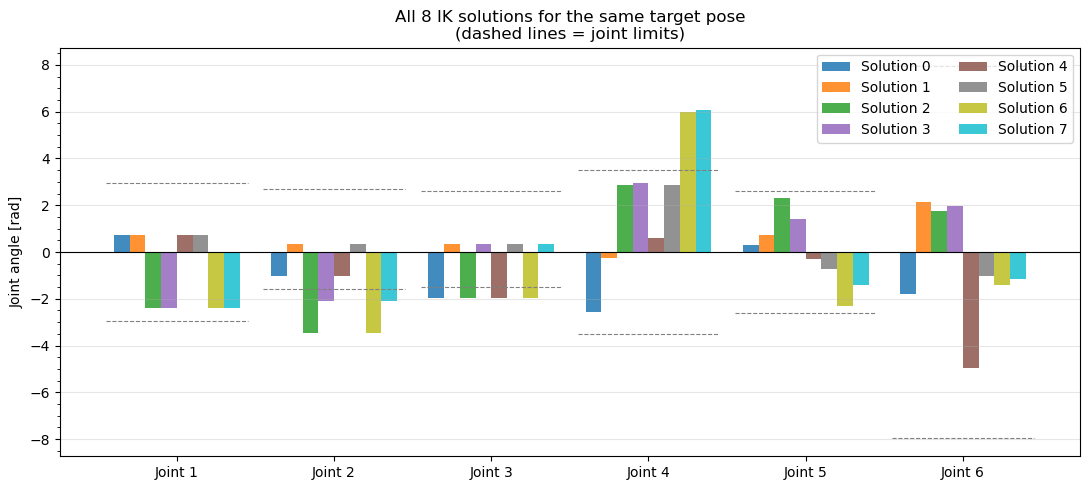

Each colored cluster is one solution. Same EE pose, wildly different joint angles.


In [7]:
n_solutions = len(valid)
n_joints = 6
x = np.arange(n_joints)
width = 0.8 / n_solutions

fig, ax = plt.subplots(figsize=(11, 5))

cmap = plt.cm.get_cmap('tab10', n_solutions)
for i, sol in enumerate(valid):
    offset = (i - n_solutions / 2 + 0.5) * width
    bars = ax.bar(x + offset, sol, width, label=f'Solution {i}', color=cmap(i), alpha=0.85)

# Also show joint limits as horizontal lines
lower_lim, upper_lim = robot.joint_limits()
for j in range(n_joints):
    ax.hlines(lower_lim[j], j - 0.45, j + 0.45, colors='gray', linestyles='--', linewidth=0.8)
    ax.hlines(upper_lim[j], j - 0.45, j + 0.45, colors='gray', linestyles='--', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels([f'Joint {i+1}' for i in range(n_joints)])
ax.set_ylabel('Joint angle [rad]')
ax.set_title(f'All {n_solutions} IK solutions for the same target pose\n(dashed lines = joint limits)', fontsize=12)
ax.legend(loc='upper right', ncol=2)
ax.axhline(0, color='black', linewidth=0.8)
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Each colored cluster is one solution. Same EE pose, wildly different joint angles.")

## Exercises

**1. Joint limit filtering**  
Not all IK solutions are reachable on the real robot — some exceed joint limits. Modify the code below to filter `valid` solutions to only those within joint limits. How many solutions remain?

```python
within_limits = opw.filter_joint_limits(valid)
print(f"{len(within_limits)} solutions within joint limits")
```

**2. Solution selection strategy**  
If the robot is currently at `q_current = np.zeros(6)`, which IK solution requires the smallest total joint motion (i.e., minimizes `np.linalg.norm(sol - q_current)`)? Why would a real system prefer this?

**3. Degenerate poses**  
Try `q_known = np.array([0.0, -np.pi/2, 0.0, 0.0, 0.0, 0.0])`. This puts the arm in a *singular configuration* (wrist singularity). How many valid solutions does IK return? What does the bar chart look like?

Hint: At singularities, joints 4 and 6 become collinear. Infinitely many combinations of `θ4 + θ6` produce the same pose — the math collapses and fewer distinct solutions exist.